# 05 — Model Interpretation and Final Conclusions

This notebook closes the project by:
- Loading the selected final model: Random Forest
- Interpreting the most important features
- Reviewing the model's behavior on the test set
- Translating the technical results into business insights
- Writing the final conclusions and next steps

In [1]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_theme(style='whitegrid')

## 1. Load processed data and the selected model

The code below is written to be flexible:
- it first looks for `best_model.joblib`
- if that file does not exist, it searches for another model file in `../models/`

In [3]:
base_dir = Path('..')
processed_dir = base_dir / 'data' / 'processed'
models_dir = base_dir / 'models'

X_train_path = processed_dir / 'X_train_processed.csv'
X_test_path = processed_dir / 'X_test_processed.csv'
y_train_path = processed_dir / 'y_train.csv'
y_test_path = processed_dir / 'y_test.csv'

X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)
y_train = pd.read_csv(y_train_path).squeeze('columns')
y_test = pd.read_csv(y_test_path).squeeze('columns')

preferred_model_path = models_dir / 'best_model.joblib'

if preferred_model_path.exists():
    model_path = preferred_model_path
else:
    candidate_models = sorted(
        [p for p in models_dir.glob('*') if p.suffix in {'.joblib', '.pkl'} and 'preprocessor' not in p.stem.lower()]
    )
    if not candidate_models:
        raise FileNotFoundError(
            "No saved model was found in ../models/. Save your selected model in notebook 04 before running this notebook."
        )
    model_path = candidate_models[0]

model = joblib.load(model_path)

print('Loaded model from:', model_path)
print('Model type:', type(model).__name__)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

Loaded model from: ..\models\best_model.joblib
Model type: RandomForestClassifier
X_train shape: (8000, 11)
X_test shape: (2000, 11)


## 2. Quick prediction review

In [4]:
y_pred = model.predict(X_test)

if hasattr(model, 'predict_proba'):
    y_proba = model.predict_proba(X_test)[:, 1]
else:
    y_proba = None

print('Classification report:')
print(classification_report(y_test, y_pred, zero_division=0))

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.85      0.88      1593
           1       0.55      0.72      0.62       407

    accuracy                           0.82      2000
   macro avg       0.74      0.78      0.75      2000
weighted avg       0.85      0.82      0.83      2000



The final Random Forest model performs strongly on non-churners and reasonably well on churners. In particular, the recall of 0.72 for class 1 means that the model identifies many customers who actually leave the bank, which is important in a churn prediction task. Although precision for churn is lower, the overall balance between recall and F1-score supports the choice of Random Forest as the final model.

## 3. Confusion matrix

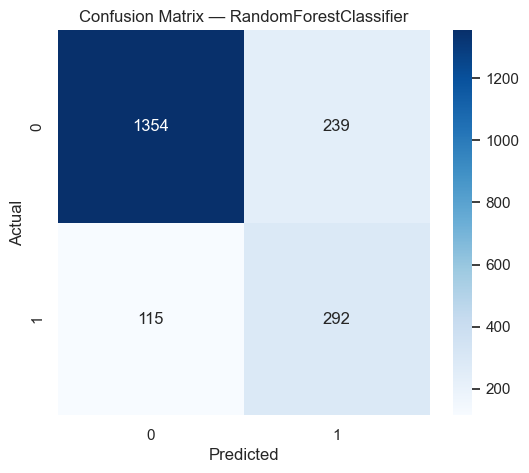

True Negatives: 1354
False Positives: 239
False Negatives: 115
True Positives: 292


In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix — {type(model).__name__}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives: {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}')
print(f'True Positives: {tp}')

The confusion matrix confirms that the Random Forest model achieves a strong balance between sensitivity to churn and overall reliability. It correctly identifies many churners (292) while keeping false negatives relatively low (115). Although the model also produces some false positives (239), this is often acceptable in churn prediction, where identifying customers at risk is usually more valuable than being overly conservative.

## 4. ROC curve

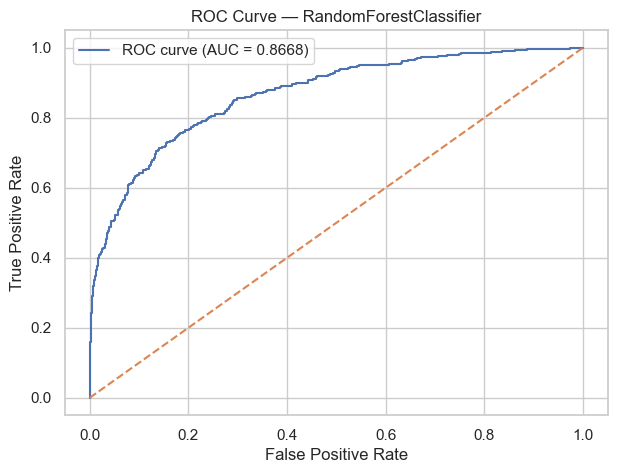

In [6]:
if y_proba is not None:
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {type(model).__name__}')
    plt.legend()
    plt.show()
else:
    print('This model does not provide predict_proba, so the ROC curve cannot be plotted.')

The ROC curve is clearly above the random baseline, and the AUC of 0.8668 indicates that the Random Forest model separates churners from non-churners quite well. This confirms that the model has strong predictive ability and supports its selection as the final model.

## 5. Feature importance

If the selected model has built-in feature importance (for example, Random Forest), we can inspect it directly.
If not, we fall back to permutation importance.

In [7]:
feature_names = X_train.columns.tolist()

if hasattr(model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)

elif hasattr(model, 'coef_'):
    coef = np.ravel(model.coef_)
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': np.abs(coef),
        'Coefficient': coef
    }).sort_values('Importance', ascending=False)

else:
    perm = permutation_importance(
        model, X_test, y_test,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': perm.importances_mean
    }).sort_values('Importance', ascending=False)

importance_df.head(15)

,Feature,Importance
1,Age,0.3647
4,NumOfProducts,0.2471
3,Balance,0.1007
8,Geography_Germany,0.0642
6,IsActiveMember,0.0618
7,EstimatedSalary,0.0510
0,CreditScore,0.0498
2,Tenure,0.0252
10,Gender_Male,0.0229
9,Geography_Spain,0.0069


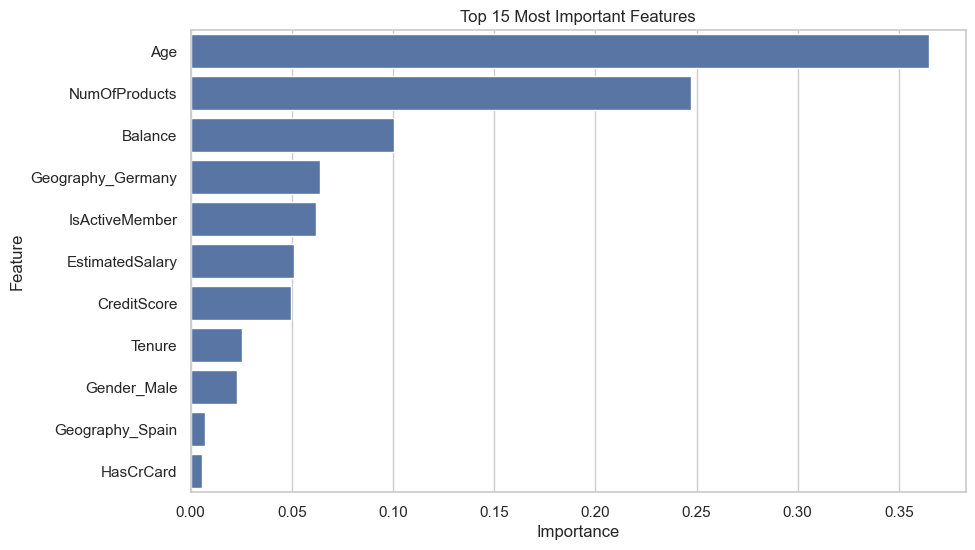

In [8]:
top_n = 15

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(top_n),
    x='Importance',
    y='Feature'
)
plt.title(f'Top {top_n} Most Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

The Random Forest model identifies ``Age``, ``NumOfProducts``, and ``Balance`` as the most important features for predicting churn. ``Geography_Germany`` and ``IsActiveMember`` also contribute meaningfully, while variables such as ``HasCrCard``, ``Geography_Spain``, and ``Gender_Male`` appear much less relevant. These results are consistent with the EDA and suggest that churn is mostly explained by customer characteristics, engagement level, and product relationship with the bank.

## 6. Business interpretation of the most important features

The most important features suggest that churn is mainly related to customer profile, engagement, and product relationship with the bank. ``Age`` indicates that older customers may have a higher tendency to leave, so this group may require more personalized retention actions. ``NumOfProducts`` suggests that the way customers use bank products is strongly linked to churn, which means the bank should pay attention to customers with unusual product patterns. ``Balance`` shows that account value is relevant, so customers with higher balances may deserve closer monitoring and proactive support. ``Geography_Germany`` indicates that churn behavior differs across markets, meaning that retention strategies may need to be adapted by country. Finally, ``IsActiveMember`` highlights the importance of engagement, since inactive customers appear to be at much higher risk of leaving the bank.

## 7. Final project conclusion

In this project, we built an end-to-end churn prediction workflow using bank customer data. After exploring the dataset, preprocessing the features, and comparing several classification models, **Random Forest** was chosen as the best final model because it offered the strongest balance between identifying churners and maintaining overall predictive performance. Although Gradient Boosting achieved slightly higher accuracy and ROC-AUC, Random Forest provided a better trade-off between precision and recall, which is especially important in a churn prediction problem.

The analysis suggests that features such as **Age, NumOfProducts, Balance, Geography_Germany, and IsActiveMember** play an important role in explaining churn. In particular, the results indicate that **older customers tend to show a higher churn risk**, **inactive customers are much more likely to leave the bank**, and **product usage patterns, especially the number of products owned, are strongly linked to retention behavior**. The model also suggests that customers from Germany and customers with higher balances may require closer attention from a business perspective.

Although the model shows useful predictive power, this project also has some limitations. For example, the dataset is relatively small, some customer behaviors are not captured, and rare groups should be interpreted carefully. Future improvements could include hyperparameter tuning, threshold optimization, explainability methods such as SHAP, and deployment in an interactive application.
